# Waste Treatment Analysis in Europe (2004-2022) #


### Note ###

1.   No API key required. Eurostat data is publicly available.
2.   Raw data is saved in 'data/raw_waste_data.csv'
3.   Output is exported to 'exports/' folder




#### Statement of use of AI ####
AI is used for explaining concepts, debugging, and suggesting alternative solutions. Project solution is conducted based on my own understanding. The code is compiled, ran, and tested by myself.


## 1. Data pipeline

![Data Pipeline](Data_pipeline.png)

## 2. Project introduction

This project explores waste treatment operations across European countries
from 2004 to 2022 using Eurostat data.

Source: Treatment of waste by waste category, hazardousness and waste management operations, Eurostat. Added to data.europa.eu on 29 April 2022 and updated on 24 September 2025.

In the first part, the project analyzes and presents the results of 3 questions below with visualization.
1. Which European countries generate the most waste?
2. How have recovery and disposal operations changed over time?
3. Are there differences between hazardous and non-hazardous waste trends?

The analysis uses exploratory data analysis, visualization, and clustering
to identify patterns in European waste management.

In the latter part, the project use supervised Machine Learning algorithms including Linear Regression and Random Forest to study  
1. The waste treatment amount (in tonnes) in a future year based on historical patterns.
2. Classification of countries as high or low waste generators.


## 3. Fetching and saving raw data

In [205]:
!pip install requests pandas matplotlib seaborn scikit-learn -q

In [206]:
import requests
import pandas as pd
import io
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

In [207]:
#Fetch waste treatment data from Eurostat API
url = "https://ec.europa.eu/eurostat/api/dissemination/sdmx/2.1/data/env_wastrt?format=SDMX-CSV&compressed=false"

response = requests.get(url)
print(f'Status code: {response.status_code}')

#Load into DataFrame
df_raw = pd.read_csv(io.StringIO(response.text))
print(f'Raw data shape: {df_raw.shape}')
display(df_raw.head())

Status code: 200
Raw data shape: (526405, 12)


,DATAFLOW,LAST UPDATE,freq,unit,hazard,wst_oper,waste,geo,TIME_PERIOD,OBS_VALUE,OBS_FLAG,CONF_STATUS
0,ESTAT:ENV_WASTRT(1.0),23/09/25 23:00:00,A,KG_HAB,HAZ,DSP_I,DSP_OTH,IS,2014,NaN,b,NaN
1,ESTAT:ENV_WASTRT(1.0),23/09/25 23:00:00,A,KG_HAB,HAZ,DSP_I,INC_OTH,AT,2004,2.0,NaN,NaN
2,ESTAT:ENV_WASTRT(1.0),23/09/25 23:00:00,A,KG_HAB,HAZ,DSP_I,INC_OTH,AT,2006,2.0,NaN,NaN
3,ESTAT:ENV_WASTRT(1.0),23/09/25 23:00:00,A,KG_HAB,HAZ,DSP_I,INC_OTH,AT,2008,NaN,NaN,C
4,ESTAT:ENV_WASTRT(1.0),23/09/25 23:00:00,A,KG_HAB,HAZ,DSP_I,INC_OTH,BE,2006,0.0,NaN,NaN


In [208]:
#Create data folder and export raw data
os.makedirs('data', exist_ok=True)
df_raw.to_csv('data/raw_waste_data.csv', index=False)
print(f'Raw data exported: {df_raw.shape[0]} rows, {df_raw.shape[1]} columns')

#Uncomment the line below to load saved data instead of calling the API
#df_raw = pd.read_csv('data/raw_waste_data.csv')

Raw data exported: 526405 rows, 12 columns


## 4. Exploratory Data Anaylysis with numerical analysis and visualization

In [235]:
display(df_raw.head())
df_raw.info()

,DATAFLOW,LAST UPDATE,freq,unit,hazard,wst_oper,waste,geo,TIME_PERIOD,OBS_VALUE,OBS_FLAG,CONF_STATUS
0,ESTAT:ENV_WASTRT(1.0),23/09/25 23:00:00,A,KG_HAB,HAZ,DSP_I,DSP_OTH,IS,2014,NaN,b,NaN
1,ESTAT:ENV_WASTRT(1.0),23/09/25 23:00:00,A,KG_HAB,HAZ,DSP_I,INC_OTH,AT,2004,2.0,NaN,NaN
2,ESTAT:ENV_WASTRT(1.0),23/09/25 23:00:00,A,KG_HAB,HAZ,DSP_I,INC_OTH,AT,2006,2.0,NaN,NaN
3,ESTAT:ENV_WASTRT(1.0),23/09/25 23:00:00,A,KG_HAB,HAZ,DSP_I,INC_OTH,AT,2008,NaN,NaN,C
4,ESTAT:ENV_WASTRT(1.0),23/09/25 23:00:00,A,KG_HAB,HAZ,DSP_I,INC_OTH,BE,2006,0.0,NaN,NaN


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 526405 entries, 0 to 526404
Data columns (total 12 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   DATAFLOW     526405 non-null  object 
 1   LAST UPDATE  526405 non-null  object 
 2   freq         526405 non-null  object 
 3   unit         526405 non-null  object 
 4   hazard       526405 non-null  object 
 5   wst_oper     526405 non-null  object 
 6   waste        526405 non-null  object 
 7   geo          526405 non-null  object 
 8   TIME_PERIOD  526405 non-null  int64  
 9   OBS_VALUE    442634 non-null  float64
 10  OBS_FLAG     82188 non-null   object 
 11  CONF_STATUS  8921 non-null    object 
dtypes: float64(1), int64(1), object(10)
memory usage: 48.2+ MB


In [236]:
df_raw.describe()

,TIME_PERIOD,OBS_VALUE
count,526405.000000,4.426340e+05
mean,2015.074553,1.753130e+06
std,4.834264,3.018986e+07
min,2004.000000,0.000000e+00
25%,2012.000000,0.000000e+00
50%,2016.000000,1.000000e+00
75%,2020.000000,8.150000e+02
max,2022.000000,2.383700e+09


In [237]:
#count missing value
df_raw.isna().sum()

,0
DATAFLOW,0
LAST UPDATE,0
freq,0
unit,0
hazard,0
wst_oper,0
waste,0
geo,0
TIME_PERIOD,0
OBS_VALUE,83771


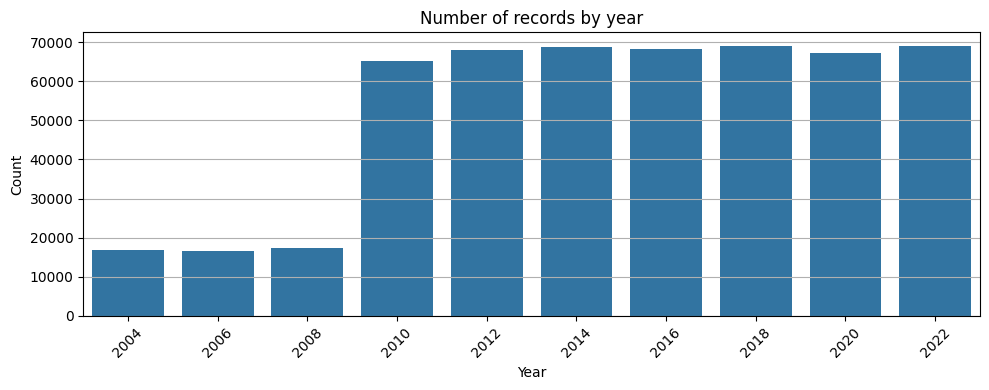

In [238]:
# Number of records over time
plt.figure(figsize=(10, 4))
sns.countplot(data=df_raw, x='TIME_PERIOD')
plt.title('Number of records by year')
plt.xlabel('Year')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.grid(axis = 'y')
plt.tight_layout()
plt.show()

###Comment ###
The number of records remarkably increased since 2010 with over 60000 records collected and stabilized over the upcoming years. The period of 2004-2008 seems to be an early stage with less than 20000 records collected in this period.

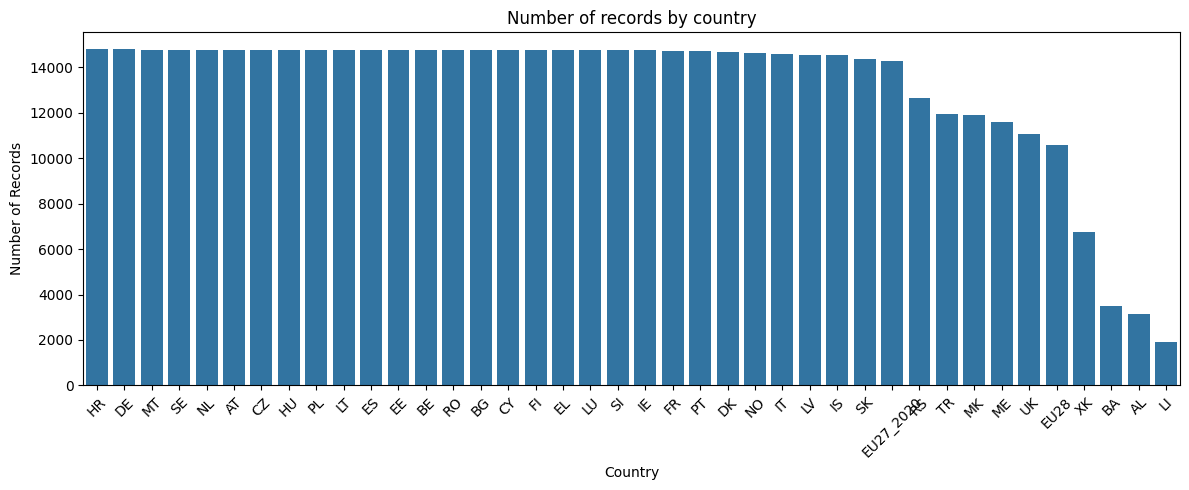

In [239]:
# Number of records by country
country_counts = df_raw['geo'].value_counts()
plt.figure(figsize=(12, 5))
sns.barplot(x=country_counts.index, y=country_counts.values)
plt.title('Number of records by country')
plt.xlabel('Country')
plt.ylabel('Number of Records')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### Comment ####
The number of records collected by EU state varies, though quite stable among the majority. Few countries seem to differ from the norm, i.e. XK (Kosovo), BA (Bosnia and Herzegovina), AL (Albania) and LI (Liechtenstein).

## 5. Data preprocessing

Steps:
1. Filter to total waste (`waste == 'TOTAL'`) to avoid double counting
2. Filter to combined hazard type (`hazard == 'HAZ_NHAZ'`) to avoid double counting
3. Filter to tonnes unit (`unit == 'T'`) for consistency
4. Exclude EU aggregates (`EU27_2020`, `EU28`) — keep individual countries only
5. Drop rows with missing values in `OBS_VALUE`
6. Rename columns for clarity
7. Keep only relevant columns

In [214]:
#Filter to meaningful subset
df_clean = df_raw[
    (df_raw['waste'] == 'TOTAL') &
    (df_raw['hazard'] == 'HAZ_NHAZ') &
    (df_raw['unit'] == 'T') &
    (~df_raw['geo'].isin(['EU27_2020', 'EU28']))
].dropna(subset=['OBS_VALUE']).copy()

#Rename columns for clarity
df_clean = df_clean.rename(columns={
    'geo': 'country',
    'TIME_PERIOD': 'year',
    'OBS_VALUE': 'tonnes',
    'wst_oper': 'operation',
    'hazard': 'hazard_type'
})

#Keep only relevant columns
df_clean = df_clean[['country', 'year', 'operation', 'hazard_type', 'waste', 'tonnes']]

print(f'Clean data shape: {df_clean.shape}')
print(f'\nOperations available:')
print(df_clean['operation'].value_counts())
display(df_clean.head())

Clean data shape: (2777, 6)

Operations available:
operation
TRT          333
DSP_L        331
DSP_L_OTH    330
RCV_R_B      328
RCV_E        327
DSP_I        325
DSP_OTH      324
RCV_R        240
RCV_B        239
Name: count, dtype: int64


,country,year,operation,hazard_type,waste,tonnes
350414,AL,2014,DSP_I,HAZ_NHAZ,TOTAL,38095.0
350415,AL,2022,DSP_I,HAZ_NHAZ,TOTAL,122629.0
350416,AT,2004,DSP_I,HAZ_NHAZ,TOTAL,1858338.0
350417,AT,2006,DSP_I,HAZ_NHAZ,TOTAL,1398793.0
350418,AT,2008,DSP_I,HAZ_NHAZ,TOTAL,1593693.0


In [215]:
#Operation code reference
operation_labels = {
    'TRT': 'Total Treatment',
    'DSP_L': 'Landfill Disposal',
    'DSP_L_OTH': 'Other Landfill',
    'DSP_I': 'Incineration',
    'DSP_OTH': 'Other Disposal',
    'RCV_R': 'Recycling',
    'RCV_R_B': 'Recycling & Backfilling',
    'RCV_E': 'Energy Recovery',
    'RCV_B': 'Backfilling'
}

# Add operation labels to df_clean
df_clean['operation_label'] = df_clean['operation'].map(operation_labels)

In [216]:
display(df_clean.head())

,country,year,operation,hazard_type,waste,tonnes,operation_label
350414,AL,2014,DSP_I,HAZ_NHAZ,TOTAL,38095.0,Incineration
350415,AL,2022,DSP_I,HAZ_NHAZ,TOTAL,122629.0,Incineration
350416,AT,2004,DSP_I,HAZ_NHAZ,TOTAL,1858338.0,Incineration
350417,AT,2006,DSP_I,HAZ_NHAZ,TOTAL,1398793.0,Incineration
350418,AT,2008,DSP_I,HAZ_NHAZ,TOTAL,1593693.0,Incineration


## 6. Findings

### Question 1.  Which countries generate the most waste?

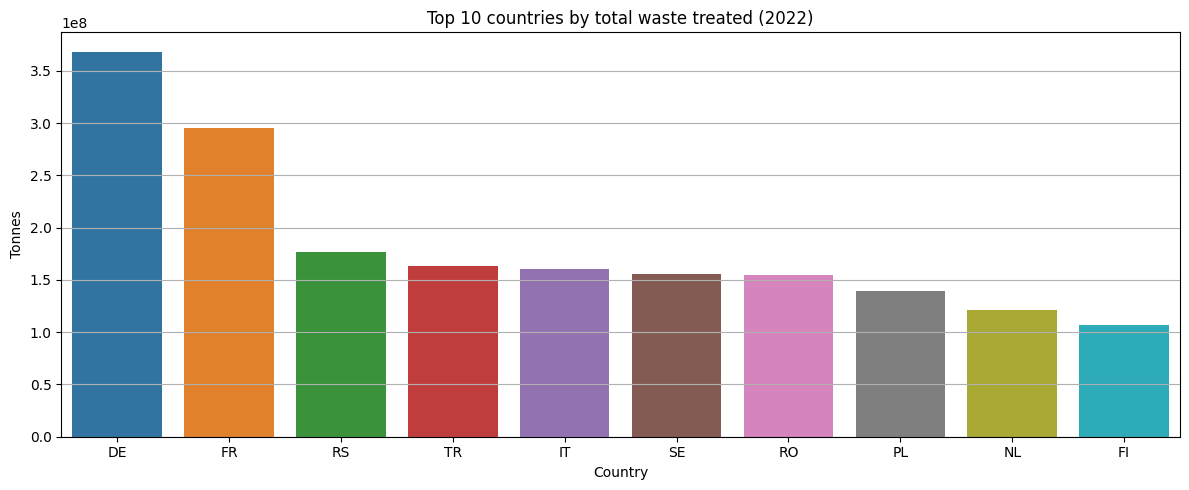


Top 10 countries by waste treated in 2022:


,country,tonnes
428150,DE,368440922.0
428228,FR,295111161.0
428387,RS,176309525.0
428427,TR,163730671.0
428277,IT,160050353.0
428397,SE,156118978.0
428380,RO,154528480.0
428360,PL,139041865.0
428340,NL,120838859.0
428218,FI,107072699.0


In [217]:
#Top 10 countries by total waste treated in latest year
latest_year = df_clean['year'].max()

top10 = (df_clean[
    (df_clean['year'] == latest_year) &
    (df_clean['operation'] == 'TRT')
]
.sort_values('tonnes', ascending=False)
.head(10))

plt.figure(figsize=(12, 5))
sns.barplot(data=top10, x='country', y='tonnes', hue = 'country')
plt.title(f'Top 10 countries by total waste treated ({latest_year})')
plt.xlabel('Country')
plt.ylabel('Tonnes')
plt.grid(axis='y')
plt.tight_layout()
plt.show()

print(f'\nTop 10 countries by waste treated in {latest_year}:')
display(top10[['country', 'tonnes']])

#### Comment ####

Germany (DE), France (FR) are the leaders in this category.


### Question 2.  How have recovery and disposal operations changed over time?

In [218]:
#Define recovery and disposal groups
recovery_ops = ['RCV_R', 'RCV_R_B', 'RCV_E', 'RCV_B']
disposal_ops = ['DSP_L', 'DSP_L_OTH', 'DSP_I', 'DSP_OTH']

#Aggregate recovery and disposal totals per year across all countries
df_trend = df_clean[df_clean['operation'].isin(recovery_ops + disposal_ops)].copy()

#Label each operation as recovery or disposal
df_trend['type'] = 'Disposal'
df_trend.loc[df_trend['operation'].isin(recovery_ops), 'type'] = 'Recovery'

#Sum by year and type
df_trend_grouped = df_trend.groupby(['year', 'type'])['tonnes'].sum().reset_index()
df_trend_grouped['tonnes'] = df_trend_grouped['tonnes'] / 1e9

print(df_trend_grouped.head(10))

   year      type    tonnes
0  2004  Disposal  2.369587
1  2004  Recovery  0.948273
2  2006  Disposal  2.182479
3  2006  Recovery  1.108459
4  2008  Disposal  2.142077
5  2008  Recovery  1.190984
6  2010  Disposal  2.242482
7  2010  Recovery  2.226631
8  2012  Disposal  2.480830
9  2012  Recovery  2.274092


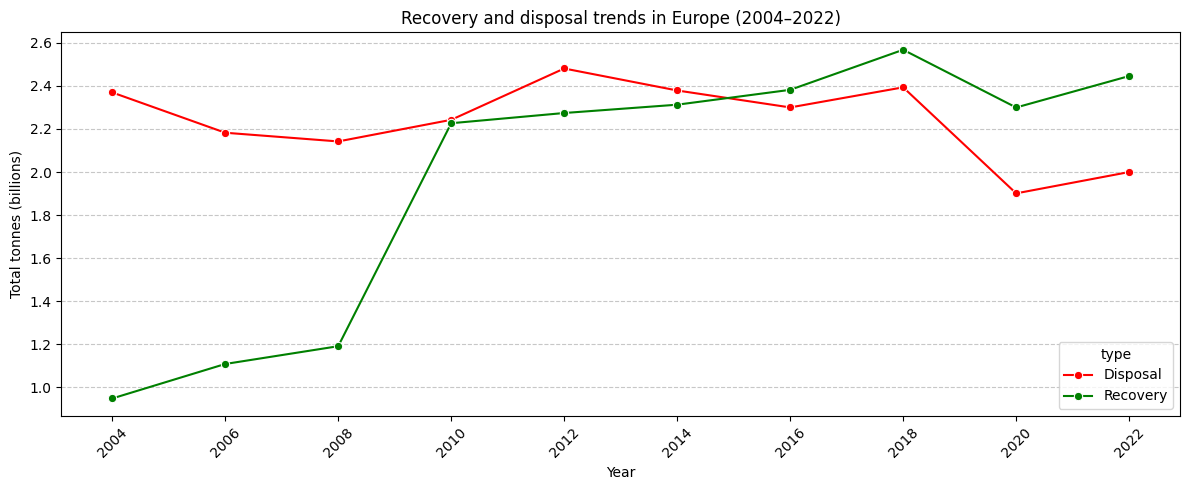

In [219]:
#Line plot recovery and disposal over time
plt.figure(figsize=(12, 5))
sns.lineplot(data=df_trend_grouped, x='year', y='tonnes',
             hue='type', marker='o', palette={'Recovery': 'green', 'Disposal': 'red'})
plt.title('Recovery and disposal trends in Europe (2004–2022)')
plt.xlabel('Year')
plt.ylabel('Total tonnes (billions)')
plt.xticks(df_trend_grouped['year'].unique(), rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

#### Comment ####

The plot shows a clear long-term shift in European waste management as disposal operations have steadily declined while recovery has increased over the years with the most notable transformation occurs afound 2008-2010. By 2022, the recovery volumes approach disposal volumes.

### Question 3.  Differences between hazardous and non-hazardous waste trends?

In [220]:
#Filter hazardous and non-hazardous waste from raw data
df_hazard = df_raw[
    (df_raw['waste'] == 'TOTAL') &
    (df_raw['wst_oper'] == 'TRT') &
    (df_raw['unit'] == 'T') &
    (df_raw['hazard'].isin(['HAZ', 'NHAZ'])) &
    (~df_raw['geo'].isin(['EU27_2020', 'EU28']))
].dropna(subset=['OBS_VALUE']).copy()

#Rename for clarity
df_hazard = df_hazard.rename(columns={
    'geo': 'country',
    'TIME_PERIOD': 'year',
    'OBS_VALUE': 'tonnes',
    'hazard': 'hazard_type'
})

#Map hazard codes to readable labels
df_hazard['hazard_label'] = df_hazard['hazard_type'].map({
    'HAZ': 'Hazardous',
    'NHAZ': 'Non-Hazardous'
})

#Aggregate by year and hazard type
df_hazard_grouped = df_hazard.groupby(['year', 'hazard_label'])['tonnes'].sum().reset_index()
df_hazard_grouped['tonnes'] = df_hazard_grouped['tonnes'] / 1e9
print(df_hazard_grouped.head(10))

   year   hazard_label    tonnes
0  2004      Hazardous  0.077194
1  2004  Non-Hazardous  2.100469
2  2006      Hazardous  0.080005
3  2006  Non-Hazardous  2.144087
4  2008      Hazardous  0.078693
5  2008  Non-Hazardous  2.207915
6  2010      Hazardous  0.089338
7  2010  Non-Hazardous  2.238185
8  2012      Hazardous  0.094475
9  2012  Non-Hazardous  2.353797


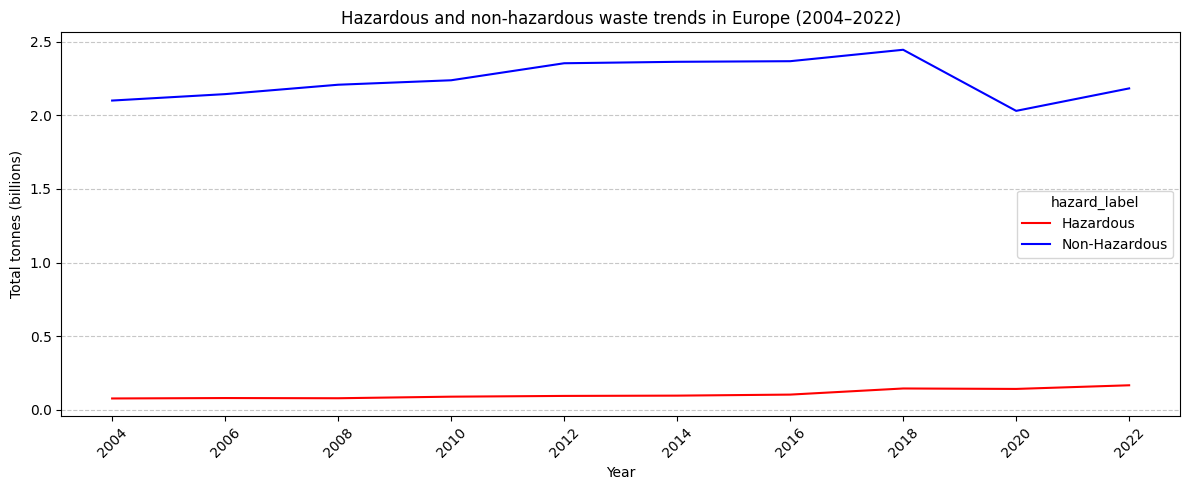

In [221]:
#Line plot hazardous and non hazardous waste over time
plt.figure(figsize=(12, 5))
sns.lineplot(data=df_hazard_grouped, x='year', y='tonnes', hue='hazard_label',
             palette={'Hazardous': 'red', 'Non-Hazardous': 'blue'})
plt.title('Hazardous and non-hazardous waste trends in Europe (2004–2022)')
plt.xlabel('Year')
plt.ylabel('Total tonnes (billions)')
plt.xticks(df_hazard_grouped['year'].unique(), rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

#### Comment ####
Non-hazardous waste dominates total treatment volumes throughout the study period. Both categories show a steady upward trend from 2004 onwards.

## 7. Supervised Machine Learning ##

In [222]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

#Use TRT operation only — total treatment per country per year
df_reg = df_clean[df_clean['operation'] == 'TRT'].copy()

#Encode categorical features
le_country = LabelEncoder()
le_operation = LabelEncoder()
le_hazard = LabelEncoder()

df_reg['country_encoded'] = le_country.fit_transform(df_reg['country'])
df_reg['operation_encoded'] = le_operation.fit_transform(df_reg['operation'])
df_reg['hazard_encoded'] = le_hazard.fit_transform(df_reg['hazard_type'])

#Features and target
X_reg = df_reg[['country_encoded', 'year', 'operation_encoded', 'hazard_encoded']]
y_reg = df_reg['tonnes']

#Train/test split
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

print('Training set:', X_train_r.shape)
print('Test set:', X_test_r.shape)


Training set: (266, 4)
Test set: (67, 4)


In [223]:
print(f'Mean tonnes: {y_reg.mean():,.0f}')
print(f'Max tonnes: {y_reg.max():,.0f}')
print(f'Min tonnes: {y_reg.min():,.0f}')

Mean tonnes: 70,593,773
Max tonnes: 387,770,912
Min tonnes: 395,251


### 1. Predict waste treatment amount (tonnes) in the future year based on historical patterns.


In [224]:
from sklearn.linear_model import LinearRegression
#Linear Regression
#Train
lr_reg = LinearRegression()
lr_reg.fit(X_train_r, y_train_r)
#Predict on test set
y_pred_lr_r = lr_reg.predict(X_test_r)
#Evaluate
print('Linear Regression')
print(f'MAE: {mean_absolute_error(y_test_r, y_pred_lr_r):,.0f} tonnes')
print(f'R² Score: {r2_score(y_test_r, y_pred_lr_r):.4f}')

Linear Regression
MAE: 75,732,725 tonnes
R² Score: -0.0263


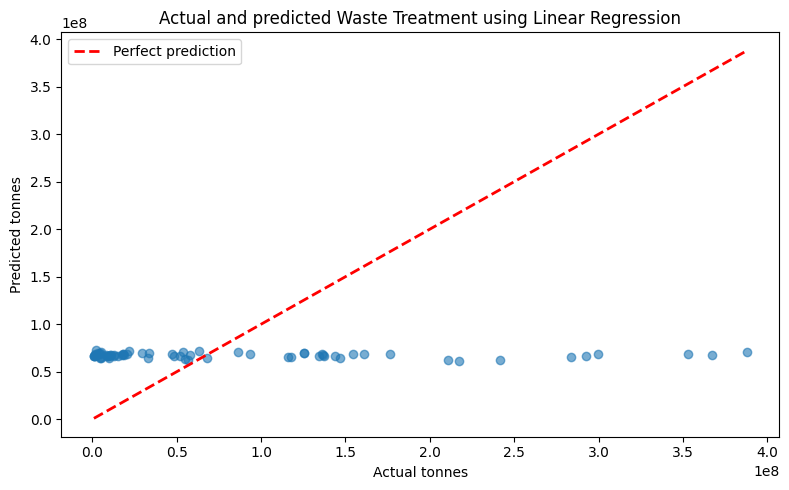

In [225]:
#Linear Regression actual vs predicted on scatter plot
plt.figure(figsize=(8, 5))
plt.scatter(y_test_r, y_pred_lr_r, alpha=0.6)
plt.plot([y_test_r.min(), y_test_r.max()],
         [y_test_r.min(), y_test_r.max()],
         'r--', linewidth=2, label='Perfect prediction')
plt.title('Actual and predicted Waste Treatment using Linear Regression')
plt.xlabel('Actual tonnes')
plt.ylabel('Predicted tonnes')
plt.legend()
plt.tight_layout()
plt.show()

In [226]:
#Random Forest Regression
from sklearn.ensemble import RandomForestRegressor
#Train
rf_reg = RandomForestRegressor(n_estimators=100, random_state=42)
rf_reg.fit(X_train_r, y_train_r)
#Predict on test set
y_pred_rf_r = rf_reg.predict(X_test_r)
#Evaluation
print('Random Forest Regression')
print(f'MAE: {mean_absolute_error(y_test_r, y_pred_rf_r):,.0f} tonnes')
print(f'R² Score: {r2_score(y_test_r, y_pred_rf_r):.4f}')

Random Forest Regression
MAE: 11,351,776 tonnes
R² Score: 0.9611


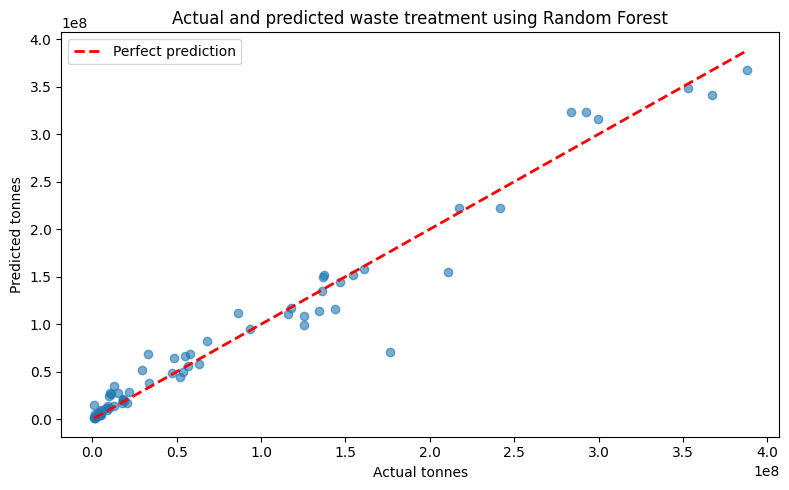

In [227]:
#Visualize Random Forest waste treatmeant actual vs predicted on scatter plot
plt.figure(figsize=(8, 5))
plt.scatter(y_test_r, y_pred_rf_r, alpha=0.6)
plt.plot([y_test_r.min(), y_test_r.max()],
         [y_test_r.min(), y_test_r.max()],
         'r--', linewidth=2, label='Perfect prediction')
plt.title('Actual and predicted waste treatment using Random Forest')
plt.xlabel('Actual tonnes')
plt.ylabel('Predicted tonnes')
plt.legend()
plt.tight_layout()
plt.show()

#### Evaluation ####
The MAE of 11.4M tonnes from Random Forest represents approximately 16% of the mean waste treatment volume (70.6M tonnes). Given the wide range of values from min of  395,000 tonnes to 388M tonnes, this could be taken as a reasonable error margin.

The R² of 0.96 confirms Random Forest captures the underlying patterns
in European waste treatment data very well, while Linear Regression's
R²=-0.03 confirms the relationship is non-linear and cannot be captured
by a straight line model.

### 2. Classification: high/low waste generators ###

In [228]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

#Use TRT operation — one row per country per year
df_clf = df_clean[df_clean['operation'] == 'TRT'].copy()

#Create binary target — above or below median
median_tonnes = df_clf['tonnes'].median()
df_clf['high_waste'] = (df_clf['tonnes'] > median_tonnes).astype(int)

print(f'Median tonnes: {median_tonnes:,.0f}')
print(f'\nClass balance:')
print(df_clf['high_waste'].value_counts())

Median tonnes: 20,911,204

Class balance:
high_waste
0    167
1    166
Name: count, dtype: int64


In [229]:
#Encode and split
#Reuse encoded columns from regression
df_clf['country_encoded'] = le_country.transform(df_clf['country'])
df_clf['operation_encoded'] = le_operation.transform(df_clf['operation'])
df_clf['hazard_encoded'] = le_hazard.transform(df_clf['hazard_type'])

#Features and target
X_clf = df_clf[['country_encoded', 'year', 'operation_encoded', 'hazard_encoded']]
y_clf = df_clf['high_waste']

#Train/test split
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42
)

print('Training set:', X_train_c.shape)
print('Test set:', X_test_c.shape)

Training set: (266, 4)
Test set: (67, 4)


In [230]:
#Train and evaluate
#Logistic Regression
lr_clf = LogisticRegression(random_state=42, max_iter=1000)
lr_clf.fit(X_train_c, y_train_c)

y_pred_lr_c = lr_clf.predict(X_test_c)

print(f'Accuracy: {accuracy_score(y_test_c, y_pred_lr_c):.4f}')
print(confusion_matrix(y_test_c, y_pred_lr_c))
print(classification_report(y_test_c, y_pred_lr_c))


Accuracy: 0.5522
[[18 12]
 [18 19]]
              precision    recall  f1-score   support

           0       0.50      0.60      0.55        30
           1       0.61      0.51      0.56        37

    accuracy                           0.55        67
   macro avg       0.56      0.56      0.55        67
weighted avg       0.56      0.55      0.55        67



In [231]:
#Random Forest Classification
rf_clf = RandomForestClassifier(n_estimators=100, random_state=42)
rf_clf.fit(X_train_c, y_train_c)
y_pred_rf_c = rf_clf.predict(X_test_c)

print('Random Forest Classification')
print(f'Accuracy: {accuracy_score(y_test_c, y_pred_rf_c):.4f}')
print(confusion_matrix(y_test_c, y_pred_rf_c))
print(classification_report(y_test_c, y_pred_rf_c))


Random Forest Classification
Accuracy: 0.8806
[[24  6]
 [ 2 35]]
              precision    recall  f1-score   support

           0       0.92      0.80      0.86        30
           1       0.85      0.95      0.90        37

    accuracy                           0.88        67
   macro avg       0.89      0.87      0.88        67
weighted avg       0.88      0.88      0.88        67



#### Evaluation ####

The class balance is nearly perfect (167 vs 166). Logistic Regression with an accuracy of 55% performs just barely better than random
guessing, confirming the boundary between classifying countries as high or low waste generator is not linear. Random Forest with an accuracy of 88% outperforms in this case.

## 8. Conclusion ##

This project analyzed waste treatment operations across European countries from 2004 to 2022 using Eurostat data.

**Key findings:**

**1. Which countries generate the most waste?**
   - Countries like Germany, France, UK consistently top the rankings.
   - Significant variation exists between Western and Eastern European countries.

**2. Recovery and disposal trends:**
   - Recovery operations have generally increased over the study period.
   - Disposal operations (particularly landfill) have declined.
   
**3. Hazardous vs non-hazardous:**
   - Non-hazardous waste dominates total treatment volumes over studied time period.
   - Both categories show similar temporal trends.

**4. Machine Learning findings:**

Using supervised Machine Learning to predict the waste treatment amount (in tonnes) based on historical patterns and to classify countries as high or low waste generators.

   - Random Forest outperformed Linear Regression and Logistic Regression in both tasks.
   - Regression: R²=0.96, i.e. waste treatment amounts are highly predictable by country and year using Random Forest.
   - Classification: F1=0.88, i.e. countries can be reliably classified as high or low waste generators using Random Forest.
   - Non-linear relationships in the data explain why simpler models such as Linear Regression and Logistic Regression underperformed in this case.

**Limitations:**
- Data is biennial, meaning annual trends cannot be captured.
- Some countries have missing data for certain years, which may affect the completeness of cross-country comparisons.
- Waste categories and definitions may vary across countries.

## 9. Export results data ##

In [234]:
# Create exports folder
os.makedirs('exports', exist_ok=True)

# Export cleaned data
df_clean.to_csv('exports/clean_waste_data.csv', index=False)

# Export ML results
pd.DataFrame({'actual': y_test_r, 'predicted': y_pred_rf_r}).to_csv('exports/regression_results.csv', index=False)
pd.DataFrame({'actual': y_test_c.values, 'predicted': y_pred_rf_c}).to_csv('exports/classification_results.csv', index=False)
